<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex06_mlp%2Ccnn_%EA%B0%9C%EA%B3%A0%EC%96%91%EC%9D%B4_%EC%9D%B4%EC%A7%84%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ex06_mlp,cnn_개고양이_이진분류.ipynb

In [1]:
# 런타임 > 런타임 유형변경 > gpu t4
# 드라이브 연동
# 경로 이동
%cd '/content/drive/MyDrive/딥러닝'

/content/drive/MyDrive/딥러닝


## 목표
- mlp, cnn 모델을 활용하여 이미지 분류 실습을 진행해보자
- 이진 분류 성능을 비교해보자
- 성능을 높이기 위한 노력을 진행해보자
  - 이미지 증식
  - 전이학습

In [2]:
# npz 데이터 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FileNotFoundError: [Errno 2] No such file or directory: './data/np_cats_and_dogs.npz'

In [8]:
# keys : 딕셔너리 개념으로 데이터에 접근해야하는구나!
data['X_train'].shape
data['X_test'].shape

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# 크기 확인
print('훈련셋:', X_train.shape, y_train.shape)
print('테스트셋:', X_test.shape, y_test.shape)

# 0: cats, 1: dogs

훈련셋: (2000, 224, 224, 3) (2000,)
테스트셋: (1000, 224, 224, 3) (1000,)


### mip 모델 생성
- mlp 기반 모델 생성
- 모델 학습/평가 방법 설정
- 모델 학습 및 시각화
- 모델 평가 및 예측

In [9]:
# 환경 셋팅
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping

In [11]:
n_features_arr = X_train[0].shape

In [15]:
# 모델 설계 ~
# 뼈대 구축
mlp_model = Sequential()
# 입력층
# 3차원 -> 1차원: mlp는 1차원 데이터만 받아들인다!
mlp_model.add(Flatten(input_shape=(224,224,3)))
# 224 * 224 * 3 => 특성의 개수


# 중간층
mlp_model.add(Dense(256, activation='relu'))
mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dense(64, activation='relu'))

# 이진 분류 출력층
# 0.1
# 1, sigmoid
mlp_model.add(Dense(1, activation='sigmoid'))

# 모델 요약
mlp_model.summary()

# 컴파일
mlp_model.compile(loss= 'binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

# 조기학습 중단
# 교차검증 정확도를 기준으로 5번 정도 갱신이 되지 않으면, 더이상 좋은 학습은 어렵다고 판단하여 학습 중단
f_ea = EarlyStopping(monitor='val_accuracy',
                     patience=5,
                     verbose=1)

# 학습
mlp_his = mlp_model.fit(X_train, y_train,
                        epochs=50,
                        batch_size=64,
                        validation_split=0.3,
                        callbacks=[f_ea],
                        verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │    38,535,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,576,641 (147.16 MB)

 Trainable params: 38,576,641 (147.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.5252 - loss: 3493.1523 - val_accuracy: 0.0000e+00 - val_loss: 6242.7017
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6655 - loss: 2077.1233 - val_accuracy: 0.0000e+00 - val_loss: 3294.8689
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6500 - loss: 464.7561 - val_accuracy: 0.5950 - val_loss: 146.7408
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6264 - loss: 681.9296 - val_accuracy: 0.0000e+00 - val_loss: 2539.8142
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6265 - loss: 788.4284 - val_accuracy: 0.2117 - val_loss: 508.2316
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7074 - loss: 148.4509 - val_accuracy: 0.0000e+00 - val_loss: 5146.4595
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6208 - loss: 806.0195 - val_accuracy: 0.0000e+00 - val_loss: 2394.9412
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - ac

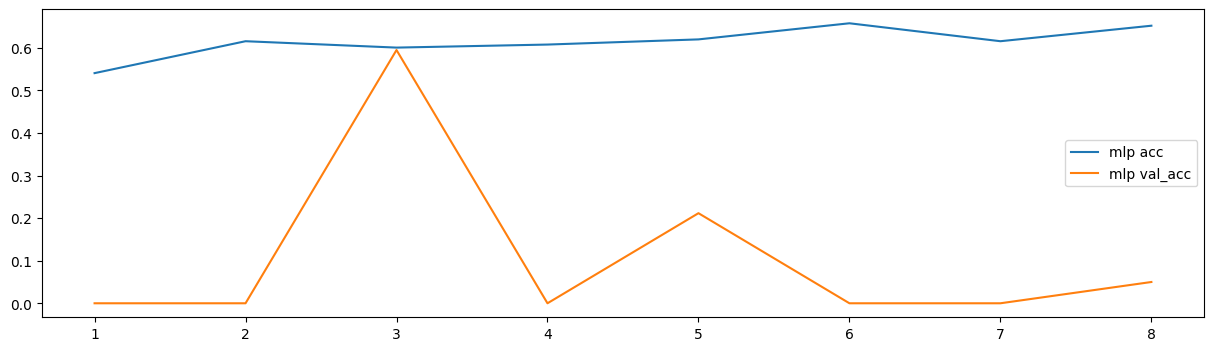

In [19]:
# mlp 시각화
plt.figure(figsize=(15,4))
# acc, val_acc
# x 축 범위- epochs 횟수만큼
x_range = range(1, len(mlp_his.history['accuracy'])+1)
plt.plot(x_range, mlp_his.history['accuracy'], label='mlp acc')
plt.plot(x_range, mlp_his.history['val_accuracy'], label='mlp val_acc')
plt.legend()
plt.show()

In [ ]:
# 데이터의 복잡도는 높은 편
# 상대적으로 모델은 단순한 편
# 이미지를 위해 하기 위한 내부적인 구조가.. mlp는 약함
# 즉, mlp특성상 이미지 대한 학습 성능이 떨어짐
